# Assignment 2 — Transfer Learning (BERT on TweetEval–Irony)

### Keanu De Cleene, kdec819, 605624678

In this assignment, you will fine-tune a pre-trained **BERT** model on the **TweetEval** *irony* subset and explore strategies to achieve strong performance under different training regimes.

- **Model:** [bert-base-uncased](https://huggingface.co/bert-base-uncased)  
- **Dataset:** [TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval/viewer/irony) → subset **`irony`** (binary labels: `non_irony`, `irony`). Use the provided `train/validation/test` splits and the dataset’s class mapping.

### Tasks
1. **Load & Inspect the Data**  
   Report split sizes, class distribution, and text length statistics (e.g., word/character histograms). Include at least one plot.
2. **Tokenization**  
   Apply the BERT tokenizer with justified `max_seq_length`; enable truncation/padding; fix random seeds for reproducibility.
3. **Standard Fine-Tuning**  
   Fine-tune `bert-base-uncased` with a small hyperparameter grid (e.g., batch size, learning rate, max_seq_length). Log training curves and select the best configuration by **validation accuracy**.
4. **Error Analysis**  
   You need to provide insights on the model's wrong predictions from each category.
5. **Fine-tuning with Limited Training Data**  
   Re-run training with only a small fraction of the training data and explore techniques to recover performance.

**Primary metric:** test **accuracy**.  
**Additional reporting:** macro-F1, confusion matrix, and brief error analysis with misclassified examples (predicted vs. gold, with short diagnoses).


 ## Task 1: Load and Inspect the Data

### Task 1.1 — Define model & dataset names (given)
- **Model:** [`bert-base-uncased`](https://huggingface.co/bert-base-uncased)  
- **Dataset:** [`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval), subset **`irony`** (binary: `non_irony`, `irony`)

> You will re-use these identifiers throughout the notebook.

---

### Task 1.2 — Load dataset & build label mappings
- Load the **train/validation/test** splits for the **`irony`** subset using `datasets.load_dataset`.
- Extract the label names from `ds["train"].features["label"].names`.
- Build **`id2label`** and **`label2id`** dictionaries for consistency with Hugging Face `AutoModelForSequenceClassification`.

**Expected artifacts**
- Printed split sizes (e.g., `{'train': N1, 'validation': N2, 'test': N3}`).
- Printed label names and a `dict` view of `id2label` / `label2id`.

---

### Task 1.3 — Plot statistical information
Produce plots and summaries that help you understand the dataset:

1. **Class distribution** (per split: train/validation/test)  
   - Bar chart with counts for `non_irony` vs. `irony` per split.
2. **Tweet length distributions** (train split)  
   - Histograms for:
     - **Character lengths** (e.g., 50 bins)
     - **Word counts** (e.g., whitespace tokenization as a proxy, still use 50 as bin size)  
   - Report key stats: mean, median, and 95th percentile for both character and word lengths.

**Notes**
- Keep axes labeled (units: “chars”, “words”) and add informative titles.
- Save or show figures inline.
- These stats will justify later choices for `max_seq_length` (e.g., 64/96/128).


In [1]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Reproducibility
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

MODEL_NAME = "bert-base-uncased"
DATASET_NAME = "cardiffnlp/tweet_eval"
SUBSET_NAME = "irony"

c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


{'train': 2862, 'test': 784, 'validation': 955}


['non_irony', 'irony']
{0: 'non_irony', 1: 'irony'}
{'non_irony': 0, 'irony': 1}
Train character stats:
mean: 77.8906359189378
median: 77.0
p95: 130.0


Train word stats:
mean: 13.605520614954576
median: 13.0
p95: 24.0


{'non_irony': 1417, 'irony': 1445}
{'non_irony': 473, 'irony': 311}




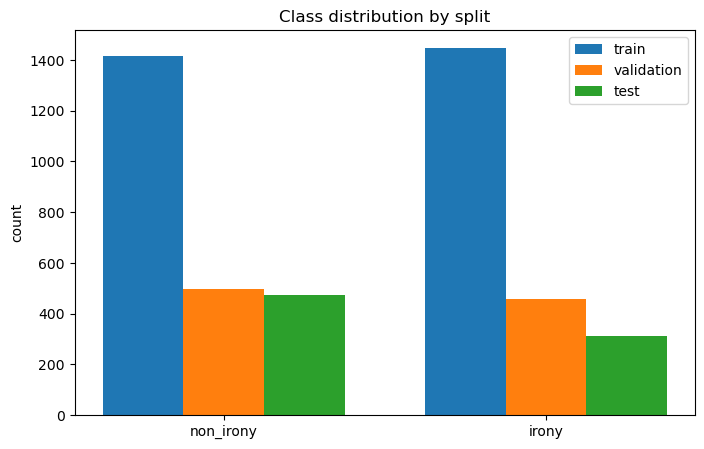

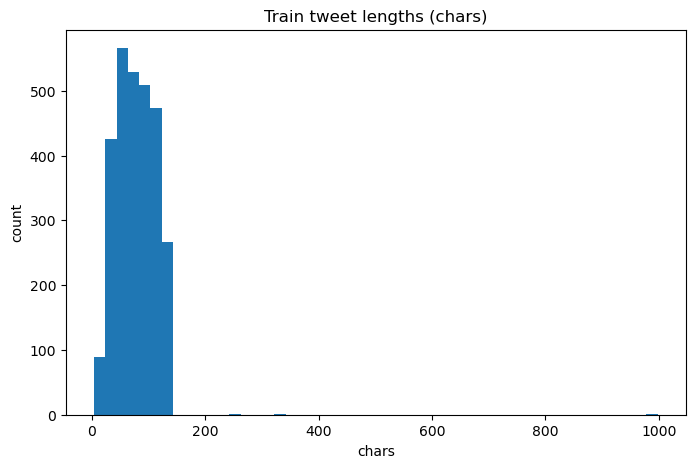

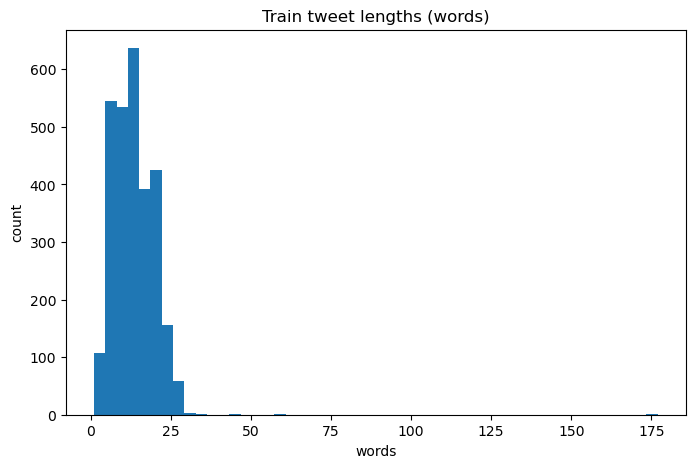

In [ ]:
# ============================================
# Task Procedure
# ============================================
# Goal: Load the TweetEval–irony dataset, build label mappings, inspect split sizes
#       and basic length statistics, then visualize class distribution and tweet
#       length histograms. Use the outputs to justify a reasonable max_seq_length.
#
# 1) Load dataset splits
#    - Use: datasets.load_dataset(DATASET_NAME, SUBSET_NAME)
#    - Expect three splits: 'train', 'validation', 'test'
#    - Immediately print the split sizes with: {split_name: len(split)}

ds = load_dataset(DATASET_NAME, SUBSET_NAME)
print({split_name: len(split) for split_name, split in ds.items()})
print("\n")
#
# 2) Extract label names and build mappings
#    - From ds["train"].features["label"].names obtain label_names
#    - Build:
#        id2label = {i: name for i, name in enumerate(label_names)}
#        label2id = {name: i for i, name in enumerate(label_names)}
#    - Print label_names and id2label for sanity check

label_names = ds["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
print(label_names)
print(id2label)
print(label2id)
print("\n")

# 3) Prepare text fields per split
#    - Extract lists:
#        train_texts = ds["train"]["text"]
#        val_texts   = ds["validation"]["text"]
#        test_texts  = ds["test"]["text"]
#    - No modifications to text content yet (keep raw tweets)

train_texts = ds["train"]["text"]
val_texts = ds["validation"]["text"]
test_texts = ds["test"]["text"]

# 4) Define helper to compute lengths
#    - lengths(texts) should return:
#        - char_lens: number of characters per tweet (len(t))
#        - word_lens: approximate token count per tweet (len(t.split()))
#    - Return numpy arrays for downstream stats and plotting

def lengths(texts):
    char_lens = np.array([len(t) for t in texts])
    word_lens = np.array([len(t.split()) for t in texts])
    return char_lens, word_lens

# 5) Compute length arrays for each split
#    - For train/validation/test texts separately:
#        train_char, train_word = lengths(train_texts)
#        val_char,   val_word   = lengths(val_texts)
#        test_char,  test_word  = lengths(test_texts)

train_char, train_word = lengths(train_texts)
val_char, val_word = lengths(val_texts)
test_char, test_word = lengths(test_texts)
#
# 6) Summarize train length statistics
#    - Print for characters and words on the TRAIN split:
#        - mean (use .mean())
#        - median (np.median)
#        - 95th percentile (np.percentile(..., 95))
#    - These numbers will inform the tokenizer max_seq_length candidates later

print("Train character stats:")
print("mean:", train_char.mean())
print("median:", np.median(train_char))
print("p95:", np.percentile(train_char, 95))
print("\n")

print("Train word stats:")
print("mean:", train_word.mean())
print("median:", np.median(train_word))
print("p95:", np.percentile(train_word, 95))
print("\n")

# 7) Compute class distribution per split
#    - Implement label_hist(split):
#        * Read split["label"]
#        * For each class index i in range(len(label_names)), count occurrences
#    - Get per-split counts:
#        train_counts = label_hist(ds["train"])
#        val_counts   = label_hist(ds["validation"])
#        test_counts  = label_hist(ds["test"])
#    - Print at least train/test class-count dicts for quick inspection

def label_hist(split):
    labels = split["label"]
    return {label_names[i]: labels.count(i) for i in range(len(label_names))}

train_counts = label_hist(ds["train"])
val_counts = label_hist(ds["validation"])
test_counts = label_hist(ds["test"])
print(train_counts)
print(test_counts)
print("\n")

# 8) Plot class distribution (bar chart)
#    - Create a grouped bar chart with bars for train/validation/test on the same x-axis
#      (x positions for classes; width ~0.25; legend for splits)
#    - Set xticks to label_names
#    - Add title: "Class distribution by split"
#    - Add y-axis label: "count"
#    - Show the figure

x = np.arange(len(label_names))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, list(train_counts.values()), width=width, label="train")
plt.bar(x, list(val_counts.values()), width=width, label="validation")
plt.bar(x + width, list(test_counts.values()), width=width, label="test")
plt.xticks(x, label_names)
plt.ylabel("count")
plt.title("Class distribution by split")
plt.legend()
plt.show()

# 9) Plot tweet length histograms on TRAIN split
#    - Two separate histograms (NO subplots):
#        (a) Characters: histogram of train_char with bins=50
#            * Title: "Train tweet lengths (chars)"
#            * x-label: "chars", y-label: "count"
#        (b) Words: histogram of train_word with bins=50
#            * Title: "Train tweet lengths (words)"
#            * x-label: "words", y-label: "count"
#    - Show each figure after configuration

plt.figure(figsize=(8, 5))
plt.hist(train_char, bins=50)
plt.title("Train tweet lengths (chars)")
plt.xlabel("chars")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_word, bins=50)
plt.title("Train tweet lengths (words)")
plt.xlabel("words")
plt.ylabel("count")
plt.show()
#
# 10) Notes / Best Practices
#    - Keep axes labels and informative titles on all plots.
#    - Do not modify text content (no preprocessing yet) to avoid biasing stats.
#    - If class imbalance is evident from the bar chart, note it for later (e.g., F1 reporting, sampling).
#    - Use these length stats to propose a justified max_seq_length grid
#      (e.g., around the 95th percentile of word or subword lengths).


# some notes:
# the training split is almost perfectly balanced 1417 non_irony vs 1445 irony, the test split is somewhat
# imbalanced toward non_irony (473 vs 311). this means macro-F1 could be important later
# because it is less sensitive to class imbalance.


# Deliverables for this step
#    - Printed: split sizes, label_names, id2label mapping
#    - Printed: train length stats (chars & words: mean/median/p95)
#    - Plots: class distribution (train/val/test), histograms of train char/word lengths
#    - Written justification (in your report/markdown): chosen max_seq_length candidates
#      for downstream tokenization based on the observed distributions.


### Task 1.3 max_seq_length justification

The dataset contains 2862 training examples, 955 validation examples, and 784 test examples. The label set is binary: `non_irony` and `irony`. The training split is almost perfectly balanced (1417 `non_irony` vs 1445 `irony`), while the test split is somewhat imbalanced toward `non_irony` (473 vs 311). This suggests that later evaluation should consider both accuracy and macro-F1.

The tweet lengths are generally short. In the training split, the mean character length is 77.89, the median is 77, and the 95th percentile is 130. For words, the mean is 13.61, the median is 13, and the 95th percentile is 24. The histograms also show a right-skewed distribution with a few long outliers, but most tweets are much shorter than these extremes.

Based on these observations, a moderate `max_seq_length` should be sufficient for downstream tokenization. Since 95% of training tweets contain about 24 words or fewer, it is unnecessary to use very large sequence lengths for most examples. However, because BERT uses subword tokenization, the true token count can be somewhat higher than the word count. Therefore, a reasonable range to test in Task 2 and Task 3 is `32`, `64`, and `96`. These values should cover most tweets while keeping padding and computation manageable.

## Task 2: Tokenization

- **Define** a tokenization function and, if needed, a helper function to tokenize the dataset.
- **Do not** hard-code `max_length`; treat it as an adjustable hyperparameter for training. The range of `max_length` can be dertmined based on your insights on data analysis above.
- If possible, you can define the following two functions here (reference only):
  1. A factory function `make_tokenize_fn(max_len)` that returns a callable to tokenize batches with the given `max_len`.
  2. A helper `prepare_datasets_for_max_len(ds, max_len)` that applies the tokenizer to all splits and prepares tensors.


In [3]:
# ============================================
# Task Procedure: Tokenization & Dataset Prep
# ============================================
# Goal: Create a reusable tokenization pipeline that (a) instantiates the
#       pretrained tokenizer, (b) provides a factory to tokenize with a chosen
#       max_len, (c) uses dynamic padding via a data collator, and (d) produces
#       tensor-ready DatasetDict splits compatible with Hugging Face Trainer.

# 1) Instantiate tokenizer
#    - Use AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True).
#    - Keep the same tokenizer instance for all runs to ensure consistency.
#    - Verify special tokens exist (CLS/SEP/PAD); fast tokenizer is preferred.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(tokenizer)
print("CLS token:", tokenizer.cls_token)
print("SEP token:", tokenizer.sep_token)
print("PAD token:", tokenizer.pad_token)

# 2) Define a tokenization factory
#    - Write make_tokenize_fn(max_len) -> callable.
#    - The returned function should accept a batch (dict with "text") and call
#      tokenizer(..., truncation=True, max_length=max_len, padding=False).
#      (Padding=False because we will rely on a collator for dynamic padding.)
#    - IMPORTANT: Do NOT hard-code max_len; pass it as the function argument
#      so you can easily sweep different max_seq_length values from your EDA.

def make_tokenize_fn(max_len):
    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_len, padding=False)
    return tokenize_fn

# 3) Build a data collator for dynamic padding
#    - Use DataCollatorWithPadding(tokenizer=tokenizer).
#    - This ensures padding is computed per-batch at runtime, minimizing waste.

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4) Prepare tokenized datasets for a given max_len
#    - Implement prepare_datasets_for_max_len(raw_ds, max_len):
#        a) Create tokenize_fn = make_tokenize_fn(max_len).
#        b) Map over all splits with batched=True to speed up:
#             raw_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
#           (Remove original "text" to avoid duplicates; keep labels.)
#        c) Rename "label" -> "labels" to match Trainer expectations.
#        d) Set tensor format for PyTorch:
#             set_format(type="torch", columns=["input_ids","attention_mask","labels"])
#        e) Return the resulting DatasetDict (train/validation/test).

def prepare_datasets_for_max_len(raw_ds, max_len):
    tokenize_fn = make_tokenize_fn(max_len)
    tokenized_ds = raw_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    tokenized_ds = tokenized_ds.rename_column("label", "labels")
    tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return tokenized_ds



# Deliverables for this step
#    - A tokenizer instance, a make_tokenize_fn factory, a DataCollatorWithPadding,
#      and a helper that returns tensor-ready tokenized DatasetDict for any max_len.


## Task 3: Standard Fine-Tuning

- **Implement** fine-tuning for BERT with a predefined hyperparameter range (e.g., `max_length`, learning rate, batch size, epochs; exact choices are up to you). You may include additional hyperparameters based on your implementation, and there is no restriction on the search space (you may even build a custom classifier head on top of BERT).
- **Model selection:** choose the **best checkpoint** according to **validation** performance.
- **Logging:** save training logs and **plot the training loss curve**.
- **Report:** evaluate the selected checkpoint on the **test** split, reporting **accuracy** and **macro-F1**, and **plot the confusion matrix**.


In [ ]:
# =========================================================
# Procedure: Metrics + Hyperparameter Search + Summaries
# =========================================================
# What you do in this cell (implementation style is up to you:
# hand-written training loop OR Hugging Face Trainer are both fine).
#
# 1) Define eval metrics
#    - compute_metrics(eval_pred):
#        * from (logits, labels) -> preds = argmax(logits, -1)
#        * report: {"accuracy": ..., "macro_f1": ...}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }
#
# 2) Specify a SMALL grid (justify values from your EDA)
#    - batch_sizes: e.g., {16, 32}
#    - learning_rates: e.g., {2e-5, 3e-5, 5e-5}
#    - max_seq_lengths: e.g., {64, 96, 128}
#    - num_epochs: up to your compute resources (e.g., 3)
#    - Selection criterion: VALIDATION ACCURACY

batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]
max_seq_lengths = [32, 64, 96]
num_epochs = 3
selection_metric = "eval_accuracy"
#
# 3) For each max_seq_length:
#    - Tokenize the dataset with that max_len (reuse your prep helper).

tokenized_datasets_by_max_len = {}
for max_len in max_seq_lengths:
    print(f"Preparing tokenized datasets for max_seq_length={max_len}")
    tokenized_datasets_by_max_len[max_len] = prepare_datasets_for_max_len(ds, max_len)
#
# 4) For each (batch_size, learning_rate) in the grid:
#    - Initialize a fresh model (label mappings set).
#    - Train on train split; evaluate on validation split.
#    - Log/collect metrics per run (val accuracy, val macro-F1, basic history).
#    - Keep track of best run by validation accuracy; also store its trainer/state.

import copy
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return {
        "eval_loss": avg_loss,
        "eval_accuracy": accuracy,
        "eval_macro_f1": macro_f1,
        "predictions": np.array(all_preds),
        "labels": np.array(all_labels),
    }

run_summaries = []
best_run = None
best_history = None
best_model_state = None

for max_len in max_seq_lengths:
    tokenized_ds = tokenized_datasets_by_max_len[max_len]

    for batch_size in batch_sizes:
        train_loader = DataLoader(tokenized_ds["train"], batch_size=batch_size, shuffle=True, collate_fn=data_collator)
        val_loader = DataLoader(tokenized_ds["validation"], batch_size=batch_size, shuffle=False, collate_fn=data_collator)

        for learning_rate in learning_rates:
            run_name = f"bert_max{max_len}_bs{batch_size}_lr{learning_rate}"
            print(f"\nStarting run: {run_name}")

            set_seed(GLOBAL_SEED)
            model = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME,
                num_labels=len(label_names),
                id2label=id2label,
                label2id=label2id,
            )
            model.to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
            history = []
            run_best_accuracy = -1.0
            run_best_state = None
            run_best_metrics = None

            for epoch in range(num_epochs):
                model.train()
                total_train_loss = 0.0

                for batch in train_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    optimizer.zero_grad()
                    outputs = model(**batch)
                    loss = outputs.loss
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item()

                avg_train_loss = total_train_loss / len(train_loader)
                eval_metrics = evaluate_model(model, val_loader)

                history.append({"epoch": epoch + 1, "loss": avg_train_loss})
                history.append({
                    "epoch": epoch + 1,
                    "eval_loss": eval_metrics["eval_loss"],
                    "eval_accuracy": eval_metrics["eval_accuracy"],
                    "eval_macro_f1": eval_metrics["eval_macro_f1"],
                })

                print(
                    f"Epoch {epoch + 1}/{num_epochs} | "
                    f"train_loss={avg_train_loss:.4f} | "
                    f"val_loss={eval_metrics['eval_loss']:.4f} | "
                    f"val_accuracy={eval_metrics['eval_accuracy']:.4f} | "
                    f"val_macro_f1={eval_metrics['eval_macro_f1']:.4f}"
                )

                if eval_metrics["eval_accuracy"] > run_best_accuracy:
                    run_best_accuracy = eval_metrics["eval_accuracy"]
                    run_best_state = copy.deepcopy(model.state_dict())
                    run_best_metrics = eval_metrics

            model.load_state_dict(run_best_state)
            run_summary = {
                "run_name": run_name,
                "max_len": max_len,
                "batch_size": batch_size,
                "learning_rate": learning_rate,
                "num_epochs": num_epochs,
                "val_accuracy": run_best_metrics["eval_accuracy"],
                "val_macro_f1": run_best_metrics["eval_macro_f1"],
                "history": history,
            }
            run_summaries.append(run_summary)
            print(
                f"Finished {run_name} | "
                f"best_val_accuracy={run_summary['val_accuracy']:.4f}, "
                f"best_val_macro_f1={run_summary['val_macro_f1']:.4f}"
            )

            if best_run is None or run_summary["val_accuracy"] > best_run["val_accuracy"]:
                best_run = {
                    "run_name": run_name,
                    "max_len": max_len,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate,
                    "num_epochs": num_epochs,
                    "val_accuracy": run_summary["val_accuracy"],
                    "val_macro_f1": run_summary["val_macro_f1"],
                }
                best_history = history
                best_model_state = copy.deepcopy(run_best_state)
#
# 5) After the grid finishes:
#    - Print a compact leaderboard (top-N by val accuracy; include macro-F1).
#    - Report the best configuration (max_len, batch_size, lr, epochs).

leaderboard = sorted(run_summaries, key=lambda x: x["val_accuracy"], reverse=True)
top_n = min(5, len(leaderboard))
print("\nTop validation runs:")
for i, run in enumerate(leaderboard[:top_n], start=1):
    print(
        f"{i}. {run['run_name']} | max_len={run['max_len']} | "
        f"batch_size={run['batch_size']} | lr={run['learning_rate']} | "
        f"val_accuracy={run['val_accuracy']:.4f} | val_macro_f1={run['val_macro_f1']:.4f}"
    )

print("\nBest configuration:")
print(best_run)
#
# 6) Plot curves for the BEST run only (per-epoch):
#    - Training loss
#    - Validation loss
#    - Validation accuracy
#    - Validation macro-F1

train_epochs = [entry["epoch"] for entry in best_history if "loss" in entry and "eval_loss" not in entry]
train_losses = [entry["loss"] for entry in best_history if "loss" in entry and "eval_loss" not in entry]

eval_epochs = [entry["epoch"] for entry in best_history if "eval_loss" in entry]
eval_losses = [entry["eval_loss"] for entry in best_history if "eval_loss" in entry]
eval_accuracies = [entry["eval_accuracy"] for entry in best_history if "eval_accuracy" in entry]
eval_macro_f1s = [entry["eval_macro_f1"] for entry in best_history if "eval_macro_f1" in entry]

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, marker="o")
plt.title("Best run training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eval_epochs, eval_losses, marker="o")
plt.title("Best run validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eval_epochs, eval_accuracies, marker="o")
plt.title("Best run validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eval_epochs, eval_macro_f1s, marker="o")
plt.title("Best run validation macro-F1")
plt.xlabel("epoch")
plt.ylabel("macro-F1")
plt.show()
#
# 7) Final test evaluation (primary: Accuracy; also report Macro-F1 & CM)
#    - Choose evaluator:the best-by-validation checkpoint.
#    - Use the tokenized TEST split aligned with the chosen max_seq_length.
#    - Run evaluation to obtain metrics dict; explicitly log PRIMARY: test accuracy.
#    - Also compute/report Macro-F1 for completeness.
#    - Generate confusion matrix with class order matching label_names; plot it.
#    - Print a per-class classification report (precision/recall/F1/support).

best_test_ds = tokenized_datasets_by_max_len[best_run["max_len"]]
test_loader = DataLoader(
    best_test_ds["test"],
    batch_size=best_run["batch_size"],
    shuffle=False,
    collate_fn=data_collator,
)

best_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
best_model.load_state_dict(best_model_state)
best_model.to(device)

test_metrics = evaluate_model(best_model, test_loader)
print("Test accuracy:", test_metrics["eval_accuracy"])
print("Test macro-F1:", test_metrics["eval_macro_f1"])

cm = confusion_matrix(test_metrics["labels"], test_metrics["predictions"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion matrix on test split")
plt.show()

print(classification_report(test_metrics["labels"], test_metrics["predictions"], target_names=label_names))


Preparing tokenized datasets for max_seq_length=32
Preparing tokenized datasets for max_seq_length=64
Preparing tokenized datasets for max_seq_length=96
Using device: cuda

Starting run: bert_max32_bs16_lr2e-05


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Task 4: Error Analysis

**Goal:** Show ≥3 misclassified examples *per class*, include the **predicted** vs. **gold** labels, and add a brief **diagnosis** explaining why the model likely failed.

**Recommended workflow (reference only):**
1. Build a **keyword dictionary** to annotate cues in each tweet (e.g., sarcasm markers, negation, contrast).
2. For the test split, collect instances where `prediction ≠ gold`.
3. For each **class**, present at least **three** examples with:
   - **Text** (original tweet)
   - **Predicted** vs. **Gold** label
   - **Diagnosis** (short justification using detected cues)

**Example keyword dictionary (customize as needed):**
```python
sarcasm_markers = [
    "yeah right", "as if", "sure jan", "great job", "love that for me",
    "what could go wrong", "nice one", "so fun", "totally", "obviously",
]
irony_hashtags = ["#irony", "#sarcasm", "#sarcastic", "#totally", "#yeahright"]
negation_markers = [" not ", "n't ", " never ", " no ", " hardly ", " scarcely ", " without "]
contrast_markers = [" but ", " however", " though", " yet "]
```
**Suggested reporting format (per class):**

**Class:** non_irony (or irony)

**Example 1**  
**Text:** “...”  
**Pred → Gold:** non_irony → irony  
**Diagnosis:** contains sarcasm marker (“yeah right”) and contrast (“but”), likely misread.

**Example 2**  
**Text:** “...”  
**Pred → Gold:** …  
**Diagnosis:** negation and rhetorical phrasing; sentiment is ambiguous.

**Example 3**  
**Text:** “...”  
**Pred → Gold:** …  
**Diagnosis:** hashtag “#sarcastic” suggests irony; model failed to leverage it.

**Notes:**
- You may design your own dictionaries or import third-party lexicons.
- Keep diagnoses concise (one to two sentences).
- State some actionable takeaways after diagonisis.
- Optionally add automatic tags (e.g., `tags = {"sarcasm": True, "negation": False, ...}`) to support your discussion.


In [ ]:
# 8) Error Analysis (irony-focused) — Procedure (no code)
# -------------------------------------------------------
# Goal: Show ≥3 misclassified examples per GOLD class with a brief diagnosis
#       highlighting irony cues. Keep it concise and evidence-based.

from collections import Counter, defaultdict

# 1) Collect errors
#    - From test predictions, get indices where y_pred != y_true.
#    - Keep raw texts for those indices.
y_true = test_metrics["labels"]
y_pred = test_metrics["predictions"]
test_texts = ds["test"]["text"]
error_indices = [i for i, (gold, pred) in enumerate(zip(y_true, y_pred)) if gold != pred]
print(f"Total misclassified test examples: {len(error_indices)}")

# 2) Lightweight diagnostics (heuristics; reference only, you should implemnt yours)
#    - For each text, flag presence of cues (True/False or tags):
#        * sarcasm markers (e.g., "yeah right", "as if", "great job")
#        * irony hashtags (#sarcasm, #irony, #sarcastic)
#        * negation (" not ", "n't ", "never", "no")
#        * contrast (" but ", "however", "though", "yet")
#        * quotation cues (“ ” ' ")
#        * rhetorical question (?) / phrases ("who would have thought")
#        * hyperbole/intensifiers ("literally", "absolutely", "best/worst day ever")
#        * emojis suggesting irony (🙄 😒 😏 😂 🤣)
#        * suspicious positive hashtags in negative context (#awesome, #perfect)
#    - If none matched and text is very short, tag as "short/context-dependent".
sarcasm_markers = [
    "yeah right", "as if", "sure jan", "great job", "love that for me",
    "what could go wrong", "nice one", "so fun", "totally", "obviously",
]
irony_hashtags = ["#irony", "#sarcasm", "#sarcastic", "#totally", "#yeahright"]
negation_markers = [" not ", "n't ", " never ", " no ", " hardly ", " scarcely ", " without "]
contrast_markers = [" but ", " however", " though", " yet "]
hyperbole_markers = ["literally", "absolutely", "best ever", "worst ever", "so much fun"]
positive_hashtags = ["#awesome", "#perfect", "#blessed", "#bestdayever"]

def detect_cues(text):
    t = f" {text.lower()} "
    tags = []

    if any(marker in t for marker in sarcasm_markers):
        tags.append("sarcasm marker")
    if any(tag in t for tag in irony_hashtags):
        tags.append("irony hashtag")
    if any(marker in t for marker in negation_markers):
        tags.append("negation")
    if any(marker in t for marker in contrast_markers):
        tags.append("contrast")
    if '"' in text or "'" in text:
        tags.append("quotation cue")
    if "?" in text:
        tags.append("rhetorical/question cue")
    if any(marker in t for marker in hyperbole_markers):
        tags.append("hyperbole/intensifier")
    if any(tag in t for tag in positive_hashtags):
        tags.append("positive hashtag")
    if not tags and len(text.split()) <= 4:
        tags.append("short/context-dependent")
    if not tags:
        tags.append("subtle/context-dependent")
    return tags

def make_diagnosis(tags):
    if tags == ["short/context-dependent"]:
        return "Short tweet with limited context, so the model lacked enough information to infer tone."
    if tags == ["subtle/context-dependent"]:
        return "The irony seems implicit rather than explicitly signaled, so the model relied on surface meaning."
    return "Contains " + ", ".join(tags) + ", which may have made the intended tone harder for the model to interpret correctly."

# 3) Group & sample
#    - Group misclassified examples by GOLD label (non_irony, irony).
#    - For each GOLD class, show at least 3 examples (or as many as available).
errors_by_gold = defaultdict(list)
all_error_tags = Counter()

for idx in error_indices:
    gold_id = int(y_true[idx])
    pred_id = int(y_pred[idx])
    text = test_texts[idx]
    tags = detect_cues(text)
    all_error_tags.update(tags)
    errors_by_gold[label_names[gold_id]].append({
        "text": text,
        "pred_label": label_names[pred_id],
        "gold_label": label_names[gold_id],
        "tags": tags,
        "diagnosis": make_diagnosis(tags),
    })

# 4) Report format (per example)
#    - Text: "…"
#    - Gold: <gold_label>
#    - Pred: <pred_label>
#    - Diagnosis: short reason using the detected tags (e.g., "sarcasm phrase + contrast").
for gold_label in label_names:
    print(f"\nClass: {gold_label}")
    examples = errors_by_gold[gold_label][:3]
    if not examples:
        print("No misclassified examples found for this class.")
        continue

    for i, ex in enumerate(examples, start=1):
        print(f"\nExample {i}")
        print(f"Text: {ex['text']}")
        print(f"Gold: {ex['gold_label']}")
        print(f"Pred: {ex['pred_label']}")
        print(f"Tags: {', '.join(ex['tags'])}")
        print(f"Diagnosis: {ex['diagnosis']}")

# 5) Tie-back
#    - Briefly state 1–2 actionable takeaways.
print("\nMost common detected cues among errors:", all_error_tags.most_common(5))
print("Takeaway 1: The errors seem to come from tweets where the irony is really subtle or depends on context, " \
"so the model has a hard time when the meaning is not obvious from the words alone.")
print("Takeaway 2: The model struggles with cues like quotation marks, negation, and rhetorical " \
"questions, which shows that tone in tweets is still quite tricky")


Total misclassified test examples: 229

Class: non_irony

Example 1
Text: @user He is exactly that sort of person. Weirdo!
Gold: non_irony
Pred: irony
Tags: subtle/context-dependent
Diagnosis: The irony appears implicit rather than explicitly signaled, so the model likely relied on surface meaning.

Example 2
Text: Corny jokes are my absolute favorite
Gold: non_irony
Pred: irony
Tags: subtle/context-dependent
Diagnosis: The irony appears implicit rather than explicitly signaled, so the model likely relied on surface meaning.

Example 3
Text: @user @user Darn, my sock joke needs fixing?
Gold: non_irony
Pred: irony
Tags: rhetorical/question cue
Diagnosis: Contains rhetorical/question cue, which may have made the intended tone harder for the model to interpret correctly.

Class: irony

Example 1
Text: So much #sarcasm at work mate 10/10 #boring 100% #dead mate full on #shit absolutely #sleeping mate can't handle the #sarcasm
Gold: irony
Pred: non_irony
Tags: irony hashtag, negation, quota

## Task 5: Fine-tuning with Limited Training Data

You now have access to **only 1% of the training data**. Complete the following:

### 5.1 Reproduce baseline with 1% data
- Train using **exactly 1%** of the original training split with  **updated optimal hyperparameters**, based on your previous defined hyperparameter range. Follow the same hyperparameter selection procedure.
- Briefly compare against the full-data setting (performance gap + key observations).

### 5.2 Improve performance with 1% training data
Explore techniques to boost performance under the 1% regime. There is **no restriction** on the method; you may change model families, objectives, or inference strategies. Examples include (not exhaustive):

- **Data augmentation (simple):** synonym/emoji substitutions, back-translation, paraphrasing, template-based augmentation, or class-balanced resampling.
- **Prompt-based / in-context learning (advanced):** reformulate the task as few-shot prompting with instruction templates and exemplars; optionally apply lightweight calibration or verbalizer tuning.
- **Model switching or adaptation:** replace BERT with a stronger **pretrained** encoder (e.g., RoBERTa, DeBERTa) or call **LLMs** (e.g., DeepSeek, Gemini) via official APIs; consider parameter-efficient tuning (LoRA/PEFT), layer freezing, or adapters.

> **Important:** These example approaches are suggestions only. **We do not guarantee any of them will work.** You should assess feasibility and think carefully before you try them.

> **Grading note:** If your improved method performs **worse** than the naive 1% baseline (5.1) or fails to meet the specified accuracy threshold in the marking criteria, **no marks** will be awarded.

### Practical constraints & responsibility
- All approaches depend on **your available compute and budget**.
- Some LLM providers offer **free-tier** access—verify current limits before use.
- You are responsible for **API usage**, **costs**, and compliance with provider policies.

### Deliverables
- Result comparison of fine-tuned pre-trained model under challenging and standard settings, associated with its concise discussion.
- A brief **method description**.
- A **performance report** including test **Accuracy**, **Macro-F1**, and a **confusion matrix**.
- A description on **why the gains can occur**.

1% train subset size: 29
max_len=32: train=29, validation=955, test=784
max_len=64: train=29, validation=955, test=784
max_len=96: train=29, validation=955, test=784

Starting 1% run: bert_1pct_max32_bs16_lr2e-05


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | train_loss=0.6741 | val_loss=0.7032 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.6431 | val_loss=0.7110 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 3/3 | train_loss=0.6015 | val_loss=0.7279 | val_accuracy=0.4775 | val_macro_f1=0.3232
Finished bert_1pct_max32_bs16_lr2e-05 | best_val_accuracy=0.4775, best_val_macro_f1=0.3232

Starting 1% run: bert_1pct_max32_bs16_lr3e-05


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | train_loss=0.6729 | val_loss=0.7031 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.6218 | val_loss=0.7222 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 3/3 | train_loss=0.5823 | val_loss=0.7357 | val_accuracy=0.4806 | val_macro_f1=0.3298
Finished bert_1pct_max32_bs16_lr3e-05 | best_val_accuracy=0.4806, best_val_macro_f1=0.3298

Starting 1% run: bert_1pct_max32_bs16_lr5e-05


...

Epoch 1/3 | train_loss=0.6674 | val_loss=0.7099 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.6506 | val_loss=0.7146 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 3/3 | train_loss=0.6267 | val_loss=0.7304 | val_accuracy=0.4775 | val_macro_f1=0.3232
Finished bert_1pct_max96_bs32_lr3e-05 | best_val_accuracy=0.4775, best_val_macro_f1=0.3232

Starting 1% run: bert_1pct_max96_bs32_lr5e-05


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | train_loss=0.6674 | val_loss=0.7150 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.6326 | val_loss=0.7217 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 3/3 | train_loss=0.5852 | val_loss=0.7587 | val_accuracy=0.4785 | val_macro_f1=0.3254
Finished bert_1pct_max96_bs32_lr5e-05 | best_val_accuracy=0.4785, best_val_macro_f1=0.3254


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


1% Test accuracy: 0.5369897959183674
1% Test macro-F1: 0.5331610934770306


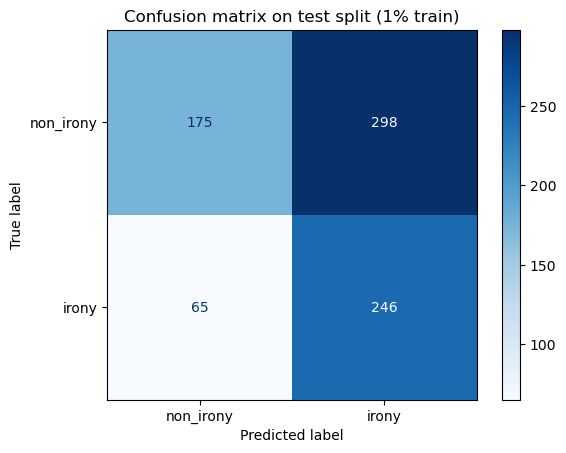

              precision    recall  f1-score   support

   non_irony       0.73      0.37      0.49       473
       irony       0.45      0.79      0.58       311

    accuracy                           0.54       784
   macro avg       0.59      0.58      0.53       784
weighted avg       0.62      0.54      0.52       784

Full-data test accuracy: 0.7079081632653061
1% test accuracy: 0.5369897959183674
Accuracy gap (full - 1%): 0.17091836734693877

Full-data test macro-F1: 0.6975629641982983
1% test macro-F1: 0.5331610934770306
Macro-F1 gap (full - 1%): 0.16440187072126777


Best 1% configuration:
{'run_name': 'bert_1pct_max64_bs16_lr5e-05', 'max_len': 64, 'batch_size': 16, 'learning_rate': 5e-05, 'num_epochs': 3, 'train_examples': 29, 'val_accuracy': 0.556020942408377, 'val_macro_f1': 0.5345747126436782}
Seed: 42
Number of training examples used: 29


In [13]:
# Task 5.1 — Naive baseline (EXACTLY 1% of train)
# ---------------------------------------------------
# Goal: Reproduce the baseline under a 1% data regime using the SAME selection procedure as before.

# 1) Data subset
#    - From the tokenized TRAIN split (for each max_seq_length), sample EXACTLY 1% with a fixed seed.

one_percent_count = max(1, round(len(ds["train"]) * 0.01))
print("1% train subset size:", one_percent_count)

tokenized_1percent_by_max_len = {}
for max_len, tokenized_ds in tokenized_datasets_by_max_len.items():
    train_subset = tokenized_ds["train"].shuffle(seed=GLOBAL_SEED).select(range(one_percent_count))
    tokenized_1percent_by_max_len[max_len] = DatasetDict({
        "train": train_subset,
        "validation": tokenized_ds["validation"],
        "test": tokenized_ds["test"],
    })
    print(
        f"max_len={max_len}: train={len(tokenized_1percent_by_max_len[max_len]['train'])}, "
        f"validation={len(tokenized_1percent_by_max_len[max_len]['validation'])}, "
        f"test={len(tokenized_1percent_by_max_len[max_len]['test'])}"
    )

# 2) Grid & selection (same as earlier)
#    - Sweep your small grid over (batch_size, learning_rate, max_seq_length, epochs).
#    - Train on the 1% subset; validate on the full VALIDATION split.
#    - Select BEST by VALIDATION ACCURACY.

run_summaries_1percent = []
best_run_1percent = None
best_history_1percent = None
best_model_state_1percent = None

for max_len in max_seq_lengths:
    tokenized_ds = tokenized_1percent_by_max_len[max_len]

    for batch_size in batch_sizes:
        train_loader = DataLoader(
            tokenized_ds["train"],
            batch_size=batch_size,
            shuffle=True,
            collate_fn=data_collator,
        )
        val_loader = DataLoader(
            tokenized_ds["validation"],
            batch_size=batch_size,
            shuffle=False,
            collate_fn=data_collator,
        )

        for learning_rate in learning_rates:
            run_name = f"bert_1pct_max{max_len}_bs{batch_size}_lr{learning_rate}"
            print(f"\nStarting 1% run: {run_name}")

            set_seed(GLOBAL_SEED)
            model = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME,
                num_labels=len(label_names),
                id2label=id2label,
                label2id=label2id,
            )
            model.to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
            history = []
            run_best_accuracy = -1.0
            run_best_state = None
            run_best_metrics = None

            for epoch in range(num_epochs):
                model.train()
                total_train_loss = 0.0

                for batch in train_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    optimizer.zero_grad()
                    outputs = model(**batch)
                    loss = outputs.loss
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item()

                avg_train_loss = total_train_loss / len(train_loader)
                eval_metrics = evaluate_model(model, val_loader)

                history.append({"epoch": epoch + 1, "loss": avg_train_loss})
                history.append({
                    "epoch": epoch + 1,
                    "eval_loss": eval_metrics["eval_loss"],
                    "eval_accuracy": eval_metrics["eval_accuracy"],
                    "eval_macro_f1": eval_metrics["eval_macro_f1"],
                })

                print(
                    f"Epoch {epoch + 1}/{num_epochs} | "
                    f"train_loss={avg_train_loss:.4f} | "
                    f"val_loss={eval_metrics['eval_loss']:.4f} | "
                    f"val_accuracy={eval_metrics['eval_accuracy']:.4f} | "
                    f"val_macro_f1={eval_metrics['eval_macro_f1']:.4f}"
                )

                if eval_metrics["eval_accuracy"] > run_best_accuracy:
                    run_best_accuracy = eval_metrics["eval_accuracy"]
                    run_best_state = copy.deepcopy(model.state_dict())
                    run_best_metrics = eval_metrics

            model.load_state_dict(run_best_state)
            run_summary = {
                "run_name": run_name,
                "max_len": max_len,
                "batch_size": batch_size,
                "learning_rate": learning_rate,
                "num_epochs": num_epochs,
                "train_examples": len(tokenized_ds["train"]),
                "val_accuracy": run_best_metrics["eval_accuracy"],
                "val_macro_f1": run_best_metrics["eval_macro_f1"],
                "history": history,
            }
            run_summaries_1percent.append(run_summary)
            print(
                f"Finished {run_name} | "
                f"best_val_accuracy={run_summary['val_accuracy']:.4f}, "
                f"best_val_macro_f1={run_summary['val_macro_f1']:.4f}"
            )

            if best_run_1percent is None or run_summary["val_accuracy"] > best_run_1percent["val_accuracy"]:
                best_run_1percent = {
                    "run_name": run_name,
                    "max_len": max_len,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate,
                    "num_epochs": num_epochs,
                    "train_examples": len(tokenized_ds["train"]),
                    "val_accuracy": run_summary["val_accuracy"],
                    "val_macro_f1": run_summary["val_macro_f1"],
                }
                best_history_1percent = history
                best_model_state_1percent = copy.deepcopy(run_best_state)

# 3) Test evaluation (reporting)
#    - Evaluate the best 1% model on TEST.
#    - Report: Test Accuracy (primary), Macro-F1, Confusion Matrix, per-class report.

best_test_ds_1percent = tokenized_1percent_by_max_len[best_run_1percent["max_len"]]
test_loader_1percent = DataLoader(
    best_test_ds_1percent["test"],
    batch_size=best_run_1percent["batch_size"],
    shuffle=False,
    collate_fn=data_collator,
)

best_model_1percent = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
best_model_1percent.load_state_dict(best_model_state_1percent)
best_model_1percent.to(device)

test_metrics_1percent = evaluate_model(best_model_1percent, test_loader_1percent)
print("1% Test accuracy:", test_metrics_1percent["eval_accuracy"])
print("1% Test macro-F1:", test_metrics_1percent["eval_macro_f1"])

cm_1percent = confusion_matrix(test_metrics_1percent["labels"], test_metrics_1percent["predictions"])
disp_1percent = ConfusionMatrixDisplay(confusion_matrix=cm_1percent, display_labels=label_names)
disp_1percent.plot(cmap="Blues")
plt.title("Confusion matrix on test split (1% train)")
plt.show()

print(classification_report(test_metrics_1percent["labels"], test_metrics_1percent["predictions"], target_names=label_names))

# 4) Comparison
#    - Briefly compare against the full-data setting: performance gap + 1–2 observations (e.g., stability, class-wise errors).

full_test_accuracy = test_metrics["eval_accuracy"]
full_test_macro_f1 = test_metrics["eval_macro_f1"]
onepercent_test_accuracy = test_metrics_1percent["eval_accuracy"]
onepercent_test_macro_f1 = test_metrics_1percent["eval_macro_f1"]

accuracy_gap = full_test_accuracy - onepercent_test_accuracy
macro_f1_gap = full_test_macro_f1 - onepercent_test_macro_f1

print("Full-data test accuracy:", full_test_accuracy)
print("1% test accuracy:", onepercent_test_accuracy)
print("Accuracy gap (full - 1%):", accuracy_gap)
print()
print("Full-data test macro-F1:", full_test_macro_f1)
print("1% test macro-F1:", onepercent_test_macro_f1)
print("Macro-F1 gap (full - 1%):", macro_f1_gap)
print()


# 5) Documentation
#    - Log best config (max_len, bs, lr, epochs), seed, and the number of training examples used (exact count at 1%).

print("\nBest 1% configuration:")
print(best_run_1percent)
print("Seed:", GLOBAL_SEED)
print("Number of training examples used:", one_percent_count)


5.1 Comparison Observations 

Compared with the full-data setting, the 1% training regime performed worse. The full-data model achieved a test accuracy of 0.708 and a macro-F1 of 0.698, while the 1% model achieved a test accuracy of 0.537 and a macro-F1 of 0.533. This gives a gap of 0.164 in macro-F1.

Something to note from the confusion matrix and classification report is that the 1% model became biased toward predicting irony. It identified many irony examples (recall = 0.73), but performed poorly on non_irony recall (0.45), misclassifying 298 non_irony tweets as irony. This shows that with very limited training data, the model learns a less stable decision boundary and struggled to work well across both classes as effectively.


I use a stronger pretrained encoder, microsoft/deberta-base, instead of the bert-base-uncased model from the 5.1 baseline, while keeping the same 1% training regime and the same validation-based model selection procedure. This is a single stronger-encoder method rather than a change to the training objective or inference rule. It can improve performance because DeBERTa uses stronger contextual representations than the baseline BERT model, which may help generalisation even when only 29 training examples are available.
1% train subset size for 5.2: 29


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\keanu\.cache\huggingface\hub\models--microsoft--deberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

...

Epoch 1/3 | train_loss=0.6892 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.6318 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 3/3 | train_loss=0.6455 | val_accuracy=0.4775 | val_macro_f1=0.3232
Finished deberta_1pct_max96_bs32_lr3e-05 | best_val_accuracy=0.4775, best_val_macro_f1=0.3232

Starting improved 1% run: deberta_1pct_max96_bs32_lr5e-05


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['pooler.dense.bias', 'classifier.bias', 'pooler.dense.weight', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | train_loss=0.6892 | val_accuracy=0.4775 | val_macro_f1=0.3232
Epoch 2/3 | train_loss=0.7003 | val_accuracy=0.4764 | val_macro_f1=0.3227
Epoch 3/3 | train_loss=0.6186 | val_accuracy=0.5309 | val_macro_f1=0.5179
Finished deberta_1pct_max96_bs32_lr5e-05 | best_val_accuracy=0.5309, best_val_macro_f1=0.5179

Best improved validation configuration:
{'run_name': 'deberta_1pct_max32_bs32_lr5e-05', 'model_name': 'microsoft/deberta-base', 'max_len': 32, 'batch_size': 32, 'learning_rate': 5e-05, 'num_epochs': 3, 'train_examples': 29, 'val_accuracy': 0.5905759162303665, 'val_macro_f1': 0.5902722228257231}
Seed: 42
Number of training examples used: 29


c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['pooler.dense.bias', 'classifier.bias', 'pooler.dense.weight', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Improved 1% Test accuracy: 0.5994897959183674
Improved 1% Test macro-F1: 0.5943794157966888


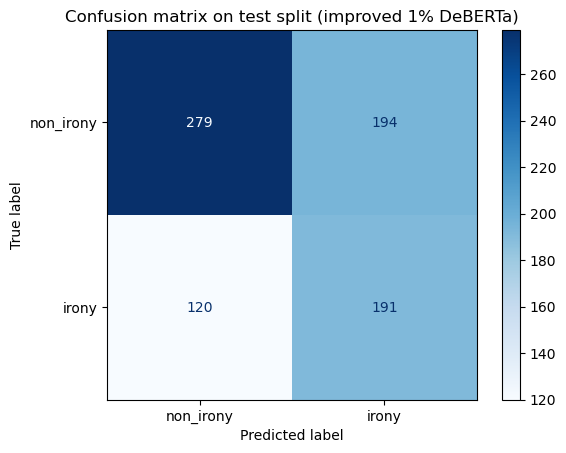

              precision    recall  f1-score   support

   non_irony       0.70      0.59      0.64       473
       irony       0.50      0.61      0.55       311

    accuracy                           0.60       784
   macro avg       0.60      0.60      0.59       784
weighted avg       0.62      0.60      0.60       784



In [ ]:
# Task 5.2 — Peroformance improvement (on the SAME 1% regime)
# -------------------------------------------------------
# Goal: Implement ONE method to improve performance under 1% data and evaluate fairly.

# 1) Choose ONE approach
#    - Example categories: simple data augmentation, PEFT/LoRA, stronger encoder (e.g., RoBERTa/DeBERTa), or prompt/in-context.
#    - State your method in 2–3 sentences (what you change vs. baseline).

improvement_method = (
    "I use a stronger pretrained encoder, microsoft/deberta-base, instead of the bert-base-uncased model from the 5.1 baseline,"
    "while keeping the same 1% training and the same validation-based model selection procedure. "
    "It can improve performance because DeBERTa uses stronger contextual representations than the baseline BERT model."
)
print(improvement_method)

# 2) Train & select
#    - Keep the 1% training budget or less.
#    - If you resort to LLMs, you can skip training but conduct predictions in zero-shot manner. You can also choose to tune the LLM.

improved_model_name = "microsoft/deberta-base"

if "GLOBAL_SEED" not in globals():
    GLOBAL_SEED = 42
    set_seed(GLOBAL_SEED)
    random.seed(GLOBAL_SEED)
    np.random.seed(GLOBAL_SEED)

improved_batch_sizes = batch_sizes if "batch_sizes" in globals() else [16, 32]
improved_learning_rates = learning_rates if "learning_rates" in globals() else [2e-5, 3e-5, 5e-5]
improved_max_seq_lengths = max_seq_lengths if "max_seq_lengths" in globals() else [32, 64, 96]
improved_num_epochs = num_epochs if "num_epochs" in globals() else 3

one_percent_count = one_percent_count if "one_percent_count" in globals() else max(1, round(len(ds["train"]) * 0.01))
print("1% train subset size for 5.2:", one_percent_count)

improved_tokenizer = AutoTokenizer.from_pretrained(improved_model_name, use_fast=True)
improved_data_collator = DataCollatorWithPadding(tokenizer=improved_tokenizer)

def make_tokenize_fn_for_tokenizer(tokenizer_instance, max_len):
    def tokenize_fn(batch):
        return tokenizer_instance(batch["text"], truncation=True, max_length=max_len)
    return tokenize_fn

def prepare_datasets_for_tokenizer_and_max_len(raw_ds, tokenizer_instance, max_len):
    tokenize_fn = make_tokenize_fn_for_tokenizer(tokenizer_instance, max_len)
    tokenized_ds = raw_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    tokenized_ds = tokenized_ds.rename_column("label", "labels")
    tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return tokenized_ds

improved_tokenized_1percent_by_max_len = {}
for max_len in improved_max_seq_lengths:
    print(f"Preparing improved datasets for max_seq_length={max_len}")
    tokenized_full_ds = prepare_datasets_for_tokenizer_and_max_len(ds, improved_tokenizer, max_len)
    train_subset = tokenized_full_ds["train"].shuffle(seed=GLOBAL_SEED).select(range(one_percent_count))
    improved_tokenized_1percent_by_max_len[max_len] = DatasetDict({
        "train": train_subset,
        "validation": tokenized_full_ds["validation"],
        "test": tokenized_full_ds["test"],
    })

run_summaries_improved = []
best_run_improved = None
best_history_improved = None
best_model_state_improved = None

for max_len in improved_max_seq_lengths:
    tokenized_ds = improved_tokenized_1percent_by_max_len[max_len]

    for batch_size in improved_batch_sizes:
        train_loader = DataLoader(
            tokenized_ds["train"],
            batch_size=batch_size,
            shuffle=True,
            collate_fn=improved_data_collator,
        )
        val_loader = DataLoader(
            tokenized_ds["validation"],
            batch_size=batch_size,
            shuffle=False,
            collate_fn=improved_data_collator,
        )

        for learning_rate in improved_learning_rates:
            run_name = f"deberta_1pct_max{max_len}_bs{batch_size}_lr{learning_rate}"
            print(f"\nStarting improved 1% run: {run_name}")

            set_seed(GLOBAL_SEED)
            model = AutoModelForSequenceClassification.from_pretrained(
                improved_model_name,
                num_labels=len(label_names),
                id2label=id2label,
                label2id=label2id,
            )
            model.to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
            history = []
            run_best_accuracy = -1.0
            run_best_state = None
            run_best_metrics = None

            for epoch in range(improved_num_epochs):
                model.train()
                total_train_loss = 0.0

                for batch in train_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    optimizer.zero_grad()
                    outputs = model(**batch)
                    loss = outputs.loss
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item()

                avg_train_loss = total_train_loss / len(train_loader)
                eval_metrics = evaluate_model(model, val_loader)

                history.append({"epoch": epoch + 1, "loss": avg_train_loss})
                history.append({
                    "epoch": epoch + 1,
                    "val_accuracy": eval_metrics["eval_accuracy"],
                    "val_macro_f1": eval_metrics["eval_macro_f1"],
                })

                print(
                    f"Epoch {epoch + 1}/{improved_num_epochs} | "
                    f"train_loss={avg_train_loss:.4f} | "
                    f"val_accuracy={eval_metrics['eval_accuracy']:.4f} | "
                    f"val_macro_f1={eval_metrics['eval_macro_f1']:.4f}"
                )

                if eval_metrics["eval_accuracy"] > run_best_accuracy:
                    run_best_accuracy = eval_metrics["eval_accuracy"]
                    run_best_state = copy.deepcopy(model.state_dict())
                    run_best_metrics = eval_metrics

            model.load_state_dict(run_best_state)
            run_summary = {
                "run_name": run_name,
                "model_name": improved_model_name,
                "max_len": max_len,
                "batch_size": batch_size,
                "learning_rate": learning_rate,
                "num_epochs": improved_num_epochs,
                "train_examples": len(tokenized_ds["train"]),
                "val_accuracy": run_best_metrics["eval_accuracy"],
                "val_macro_f1": run_best_metrics["eval_macro_f1"],
            }
            run_summaries_improved.append(run_summary)

            print(
                f"Finished {run_name} | "
                f"best_val_accuracy={run_summary['val_accuracy']:.4f}, "
                f"best_val_macro_f1={run_summary['val_macro_f1']:.4f}"
            )

            if best_run_improved is None or run_summary["val_accuracy"] > best_run_improved["val_accuracy"]:
                best_run_improved = run_summary.copy()
                best_history_improved = history
                best_model_state_improved = copy.deepcopy(run_best_state)

print("\nBest improved validation configuration:")
print(best_run_improved)
print("Seed:", GLOBAL_SEED)
print("Number of training examples used:", one_percent_count)



# 3) Test evaluation (same metrics)
#    - Evaluate on TEST and report: Accuracy, Macro-F1, Confusion Matrix.

best_test_ds_improved = improved_tokenized_1percent_by_max_len[best_run_improved["max_len"]]
test_loader_improved = DataLoader(
    best_test_ds_improved["test"],
    batch_size=best_run_improved["batch_size"],
    shuffle=False,
    collate_fn=improved_data_collator,
)

best_model_improved = AutoModelForSequenceClassification.from_pretrained(
    improved_model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
best_model_improved.load_state_dict(best_model_state_improved)
best_model_improved.to(device)

test_metrics_improved = evaluate_model(best_model_improved, test_loader_improved)
print("Improved 1% Test accuracy:", test_metrics_improved["eval_accuracy"])
print("Improved 1% Test macro-F1:", test_metrics_improved["eval_macro_f1"])

cm_improved = confusion_matrix(test_metrics_improved["labels"], test_metrics_improved["predictions"])
disp_improved = ConfusionMatrixDisplay(confusion_matrix=cm_improved, display_labels=label_names)
disp_improved.plot(cmap="Blues")
plt.title("Confusion matrix on test split (improved 1% DeBERTa)")
plt.show()

print(classification_report(test_metrics_improved["labels"], test_metrics_improved["predictions"], target_names=label_names))

# 4) Compare to 5.1
#    - Present a short side-by-side comparison with the 1% baseline.
#    - Give a concise reason why your method can yield gains (one paragraph max).

baseline_accuracy_1pct = test_metrics_1percent["eval_accuracy"]
baseline_macro_f1_1pct = test_metrics_1percent["eval_macro_f1"]
improved_accuracy_1pct = test_metrics_improved["eval_accuracy"]
improved_macro_f1_1pct = test_metrics_improved["eval_macro_f1"]

print("\n5.2 comparison against the 5.1 baseline")
print(f"Baseline 1% BERT accuracy: {baseline_accuracy_1pct:.3f}")
print(f"Improved 1% DeBERTa accuracy: {improved_accuracy_1pct:.3f}")
print(f"Accuracy gain: {improved_accuracy_1pct - baseline_accuracy_1pct:.3f}")
print()

print(f"Baseline 1% BERT macro-F1: {baseline_macro_f1_1pct:.3f}")
print(f"Improved 1% DeBERTa macro-F1: {improved_macro_f1_1pct:.3f}")
print(f"Macro-F1 gain: {improved_macro_f1_1pct - baseline_macro_f1_1pct:.3f}")
print()


